In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime



In [4]:
#Importing the dataset and change the encoding if needed (latin1 or ISO-8859-1)
df = pd.read_csv("Superstore.csv" , encoding ='latin1')

In [5]:
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2013-152156  09-11-2013  12-11-2013    Second Class    CG-12520   
1       2  CA-2013-152156  09-11-2013  12-11-2013    Second Class    CG-12520   
2       3  CA-2013-138688  13-06-2013  17-06-2013    Second Class    DV-13045   
3       4  US-2012-108966  11-10-2012  18-10-2012  Standard Class    SO-20335   
4       5  US-2012-108966  11-10-2012  18-10-2012  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [6]:
#getting some information about the dataset like, types of rows and columns 

df.info


<bound method DataFrame.info of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2013-152156  09-11-2013  12-11-2013    Second Class   
1          2  CA-2013-152156  09-11-2013  12-11-2013    Second Class   
2          3  CA-2013-138688  13-06-2013  17-06-2013    Second Class   
3          4  US-2012-108966  11-10-2012  18-10-2012  Standard Class   
4          5  US-2012-108966  11-10-2012  18-10-2012  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2011-110422  22-01-2011  24-01-2011    Second Class   
9990    9991  CA-2014-121258  27-02-2014  04-03-2014  Standard Class   
9991    9992  CA-2014-121258  27-02-2014  04-03-2014  Standard Class   
9992    9993  CA-2014-121258  27-02-2014  04-03-2014  Standard Class   
9993    9994  CA-2014-119914  05-05-2014  10-05-2014    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520      

In [7]:
#Describing the dataset
print(df.describe())

            Row ID   Postal Code         Sales     Quantity     Discount  \
count  9994.000000   9994.000000   9994.000000  9994.000000  9994.000000   
mean   4997.500000  55190.379428    229.858001     3.789574     0.156203   
std    2885.163629  32063.693350    623.245101     2.225110     0.206452   
min       1.000000   1040.000000      0.444000     1.000000     0.000000   
25%    2499.250000  23223.000000     17.280000     2.000000     0.000000   
50%    4997.500000  56430.500000     54.490000     3.000000     0.200000   
75%    7495.750000  90008.000000    209.940000     5.000000     0.200000   
max    9994.000000  99301.000000  22638.480000    14.000000     0.800000   

            Profit  
count  9994.000000  
mean     28.656896  
std     234.260108  
min   -6599.978000  
25%       1.728750  
50%       8.666500  
75%      29.364000  
max    8399.976000  


In [8]:
#check for null values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

In [10]:
#Fixing the date structure into readable format 
df['Order Date'] = pd.to_datetime(df['Order Date'], format= '%d-%m-%Y')#changing the format
#Checking the date format
print(df[['Order Date']].head())

  Order Date
0 2013-11-09
1 2013-11-09
2 2013-06-13
3 2012-10-11
4 2012-10-11


In [11]:
#Fixing the date structure into readable format 
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format= '%d-%m-%Y')#changing the format
#Checking the date format
print(df[['Ship Date']].head())

   Ship Date
0 2013-11-12
1 2013-11-12
2 2013-06-17
3 2012-10-18
4 2012-10-18


In [12]:
#Checking the shipping days 
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days
#Printing the shipping days
print(df['Shipping Days'])

0       3
1       3
2       4
3       7
4       7
       ..
9989    2
9990    5
9991    5
9992    5
9993    5
Name: Shipping Days, Length: 9994, dtype: int64


In [15]:
#printing the average shipping days by region and plotting into graph
df.groupby('Ship Mode')['Shipping Days'].median()


Ship Mode
First Class       2.0
Same Day          0.0
Second Class      3.0
Standard Class    5.0
Name: Shipping Days, dtype: float64

In [18]:
#checking if shippings fast actually turns into profit
df.groupby('Ship Mode')[['Shipping Days' , 'Profit']].mean()

,Shipping Days,Profit
Ship Mode,,
First Class,2.182055,31.839948
Same Day,0.044199,29.266591
Second Class,3.240103,29.535545
Standard Class,5.007205,27.494770


In [19]:
#Checking Region wise delivery efficiency

df.groupby('Region')[['Shipping Days' , 'Profit']].mean()

,Shipping Days,Profit
Region,,
Central,4.058115,17.092709
East,3.909761,32.135808
South,3.959877,28.857673
West,3.930066,33.849032


In [20]:
#checking the delayed orders
df['Delayed'] = df['Shipping Days'] > 5
df.groupby('Delayed')['Profit'].mean()

Delayed
False    28.488497
True     29.412198
Name: Profit, dtype: float64

In [22]:
#Checking the customers segment vs shipping 
df.groupby('Segment')['Shipping Days'].mean()

Segment
Consumer       3.942400
Corporate      4.008940
Home Office    3.922042
Name: Shipping Days, dtype: float64

In [23]:
#Checking shipping days product category wise
df.groupby('Category')['Shipping Days'].mean()

Category
Furniture          3.918906
Office Supplies    3.983405
Technology         3.924743
Name: Shipping Days, dtype: float64

In [26]:
#Checking overall shipping insight
df.groupby(['Region','Ship Mode','Segment','Delayed'])[['Shipping Days', 'Profit']].mean()

Shipping Days      Profit
Region  Ship Mode      Segment     Delayed                           
Central First Class    Consumer    False         2.300699    6.909797
                       Corporate   False         2.346535    3.443730
                       Home Office False         2.309091   43.115447
        Same Day       Consumer    False         0.036145   10.034264
                       Corporate   False         0.076923   -5.153908
                       Home Office False         0.000000   31.918192
        Second Class   Consumer    False         3.343891    3.522909
                       Corporate   False         3.146853   24.454180
                       Home Office False         3.564356   47.914102
        Standard Class Consumer    False         4.406934    6.711899
                                   True          6.341014   10.536496
                       Corporate   False         4.420139   21.780287
                                   True          6.226562   67.604811
                       Home Office False         4.418750   14.382628
                                   True          6.255102   22.045730
East    First Class    Consumer    False         2.230769   15.874981
                       Corporate   False         2.193548   22.598444
                       Home Office False         2.236559   92.429433
        Same Day       Consumer    False         0.000000   46.525617
                       Corporate   False         0.000000   78.175382
                       Home Office False         0.000000   18.028091
        Second Class   Consumer    False         3.259386   22.149941
                       Corporate   False         3.296774   15.016600
                       Home Office False         3.231707   24.021770
        Standard Class Consumer    False         4.433515   33.833952
                                   True          6.333333   29.006044
                       Corporate   False         4.422170   31.341667
                                   True          6.263566   13.070074
                       Home Office False         4.308824   50.623899
                                   True          6.280000   54.015730
South   First Class    Consumer    False         2.098214   34.607046
                       Corporate   False         2.200000   37.793361
                       Home Office False         1.906250  -12.031444
        Same Day       Consumer    False         0.020408   18.258980
                       Corporate   False         0.000000 -241.947520
                       Home Office False         0.000000   51.167779
        Second Class   Consumer    False         3.089888   33.313553
                       Corporate   False         3.254545   60.954898
                       Home Office False         3.512195   49.568188
        Standard Class Consumer    False         4.442424   31.536031
                                   True          6.325444   34.356161
                       Corporate   False         4.459091   30.827987
                                   True          6.480000   26.077835
                       Home Office False         4.378571   12.265679
                                   True          6.325000    7.099048
West    First Class    Consumer    False         2.066390   50.523170
                       Corporate   False         2.200000   46.547330
                       Home Office False         2.000000   24.510031
        Same Day       Consumer    False         0.071429   41.825947
                       Corporate   False         0.121951   48.694224
                       Home Office False         0.152174   44.490026
        Second Class   Consumer    False         3.134146   35.818912
                       Corporate   False         3.283582   28.339073
                       Home Office False         3.065217   59.050065
        Standard Class Consumer    False         4.418129   26.919156
                                   True          6.348

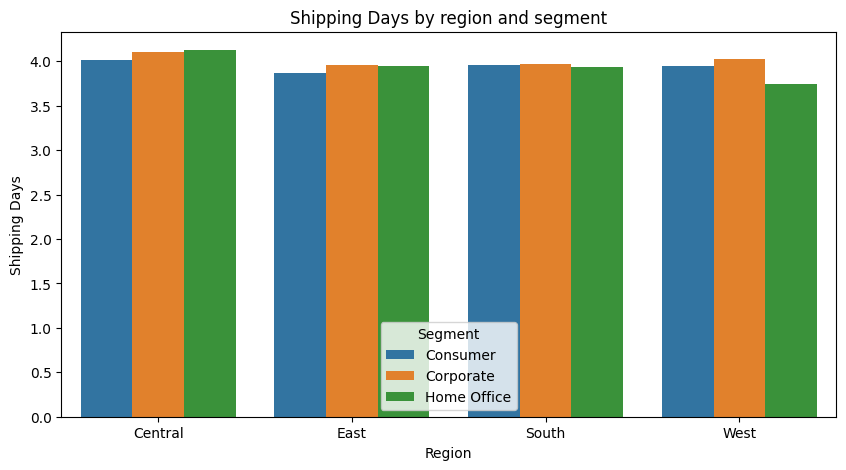

In [27]:
#Analysing insights from graph
grouped = df.groupby(['Region', 'Segment'])['Shipping Days'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=grouped, x='Region',y ='Shipping Days', hue ='Segment')
plt.title("Shipping Days by region and segment")
plt.show()

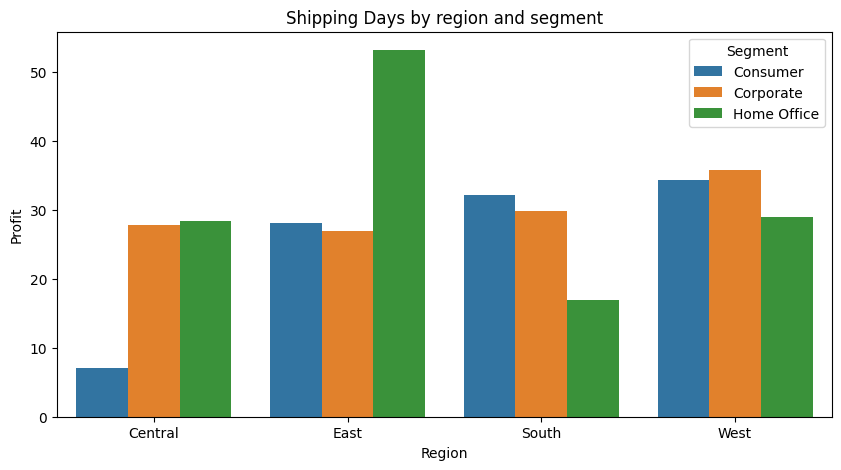

In [28]:
#Analysing insights from graph
grouped = df.groupby(['Region', 'Segment'])['Profit'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=grouped, x='Region',y ='Profit', hue ='Segment')
plt.title("Shipping Days by region and segment")
plt.show()

In [31]:
#Checking DIscount vs Profit
df.groupby([ 'Discount', 'Segment'])['Profit'].mean()

Discount  Segment    
0.00      Consumer        64.161707
          Corporate       71.584290
          Home Office     66.961384
0.10      Consumer        93.630090
          Corporate       99.802956
          Home Office     97.234865
0.15      Consumer        15.744638
          Corporate       49.282143
          Home Office     30.271889
0.20      Consumer        22.426571
          Corporate       23.157672
          Home Office     34.734830
0.30      Consumer       -48.018291
          Corporate      -46.241380
          Home Office    -37.189678
0.32      Consumer      -102.708631
          Corporate      -82.702010
          Home Office    -57.226350
0.40      Consumer       -93.462041
          Corporate     -132.003562
          Home Office   -119.900858
0.45      Consumer      -216.651900
          Corporate     -280.968633
          Home Office   -175.146900
0.50      Consumer      -253.572181
          Corporate     -388.164788
          Home Office   -377.121333
0.60  

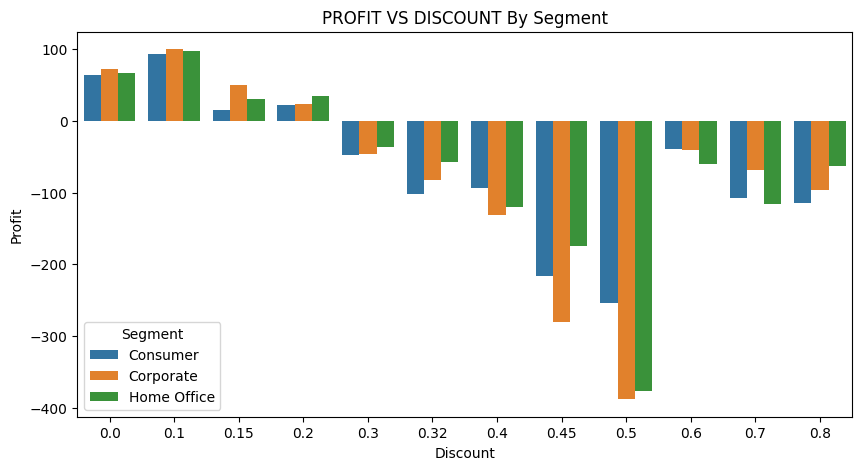

In [38]:
grouped = df.groupby(['Discount', 'Segment'])['Profit'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=grouped, x='Discount',y ='Profit', hue ='Segment')
plt.title("PROFIT VS DISCOUNT By Segment")
plt.show()

In [39]:
#Checking the volume vs profit
df.groupby(['Region', 'Segment'])[['Sales', 'Profit']].max()

Sales     Profit
Region  Segment                          
Central Consumer      9892.740  4946.3700
        Corporate    17499.950  8399.9760
        Home Office   3812.970  1906.4850
East    Consumer     10499.970  5039.9856
        Corporate     9099.930  2365.9818
        Home Office  11199.968  3919.9888
South   Consumer      8749.950  3177.4750
        Corporate     7999.980  1459.2000
        Home Office  22638.480   746.4078
West    Consumer     13999.960  6719.9808
        Corporate     5083.960  1906.4850
        Home Office   4535.976  1644.2913

In [44]:
#Checking Quantity vs Profit
df.groupby(['Region', 'Segment'])[['Quantity', 'Profit']].mean()

Quantity     Profit
Region  Segment                         
Central Consumer     3.728548   7.066046
        Corporate    3.869242  27.791831
        Home Office  3.783105  28.398202
East    Consumer     3.639891  28.040153
        Corporate    3.828962  26.935666
        Home Office  3.810757  53.205611
South   Consumer     3.792363  32.116435
        Corporate    3.952941  29.833771
        Home Office  3.731618  16.987626
West    Consumer     3.873804  34.360409
        Corporate    3.781250  35.872323
        Home Office  3.781086  28.949939

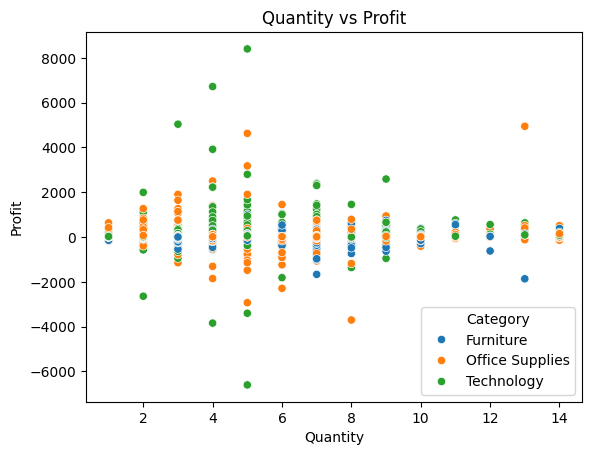

In [52]:
#Checking quantity vs profit graph
sns.scatterplot(data=df, x='Quantity',y='Profit', hue='Category')
plt.title("Quantity vs Profit")
plt.show()

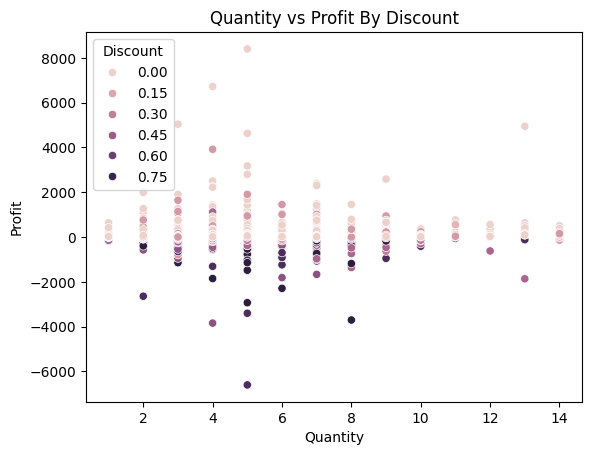

In [51]:
#Checking quantity vs profit graph by discount
sns.scatterplot(data=df, x='Quantity',y='Profit', hue='Discount')
plt.title("Quantity vs Profit By Discount")
plt.show()

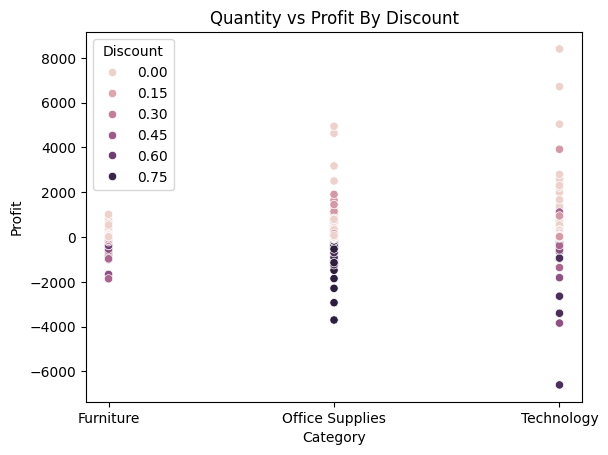

In [ ]:
#Checking category vs profit
sns.scatterplot(data=df, x='Category',y='Profit', hue='Region')
plt.title("Quantity vs Profit By Discount")
plt.show()